This project analyzes historical weather data from 2020–2023 to identify trends, seasonal patterns, and extreme weather events. Using Pandas for data manipulation, NumPy for statistical analysis, and Matplotlib for visualization, the project provides insights into temperature, humidity, wind speed, and precipitation variations over time.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load and Inspect Data & Pandas to read the weather CSV file.
df = pd.read_csv("/content/realistic_weather_data.csv")

#Display the first few rows and check data types.
print(df.head())
print(df.info())
print(df.describe())

         Date  Temperature  Humidity  Wind_Speed  Precipitation
0  2020-01-01         25.5      58.1         6.9            0.8
1  2020-01-02         22.8      59.4        13.5            0.6
2  2020-01-03         21.8      63.8         9.0            0.8
3  2020-01-04         22.8      67.8         2.2            0.1
4  2020-01-05         22.9      69.4         7.5            1.6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1461 non-null   object 
 1   Temperature    1461 non-null   float64
 2   Humidity       1461 non-null   float64
 3   Wind_Speed     1461 non-null   float64
 4   Precipitation  1461 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB
None
       Temperature     Humidity   Wind_Speed  Precipitation
count  1461.000000  1461.000000  1461.000000    1461.000000
mean     27.850034    62

In [ ]:
#Data Cleaning & missing vakue check
#datatype check and conversion

df['Date'] = pd.to_datetime(df['Date'])

#adding new columns for more accurate data

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

#adding season column for seasonal analysis

def get_season(month):
    if month in [3,4,5]:
      return 'Summer'
    elif month in [6,7,8,9]:
      return 'Monsoon'
    elif month in [10,11]:
      return 'Post Monsoon'
    else:
      return 'Winter'

df = df.assign(Season = df['Month'].apply(get_season))

#checking about updation
print(df.head())
print(df.info())

        Date  Temperature  Humidity  Wind_Speed  Precipitation  Month  Year  \
0 2020-01-01         25.5      58.1         6.9            0.8      1  2020   
1 2020-01-02         22.8      59.4        13.5            0.6      1  2020   
2 2020-01-03         21.8      63.8         9.0            0.8      1  2020   
3 2020-01-04         22.8      67.8         2.2            0.1      1  2020   
4 2020-01-05         22.9      69.4         7.5            1.6      1  2020   

   Season  
0  Winter  
1  Winter  
2  Winter  
3  Winter  
4  Winter  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1461 non-null   datetime64[ns]
 1   Temperature    1461 non-null   float64       
 2   Humidity       1461 non-null   float64       
 3   Wind_Speed     1461 non-null   float64       
 4   Precipitation  1461 non-null   float

In [ ]:
#Descriptive Statistics with NumPy
#mean, median, and standard deviation for temperature, humidity, and precipitation.

#convert col to numpy arr

temp_arr = df['Temperature'].values
hum_arr = df['Humidity'].values
pre_arr = df['Precipitation'].values

# for temperature
print('--Temperature--')
print('Mean:', np.mean(temp_arr))
print('Median:', np.median(temp_arr))
print('Standard Deviation:', np.std(temp_arr))

#for humidity
print('--Humidity--')
print('Mean:', np.mean(hum_arr))
print('Median:', np.median(hum_arr))
print('Standard Deviation:', np.std(hum_arr))

#for precipitation
print('--Precipitation--')
print('Mean:', np.mean(pre_arr))
print('Median:', np.median(pre_arr))
print('Standard Deviation:', np.std(pre_arr))

--Temperature--
Mean: 27.85003422313484
Median: 27.6
Standard Deviation: 4.781238466331646
--Humidity--
Mean: 62.95058179329228
Median: 62.1
Standard Deviation: 17.10615309331511
--Precipitation--
Mean: 3.8434633812457224
Median: 1.4
Standard Deviation: 6.18715689044011


In [ ]:
#Group data by month or season.

seasonal_val = df.groupby('Season')[['Temperature','Humidity','Precipitation']].mean().reset_index()
seasonal_ord = ['Winter', 'Summer', 'Monsoon', 'Post Monsoon']

#for making in order
seasonal_val = seasonal_val.set_index('Season').loc[seasonal_ord].reset_index()
print(seasonal_val)

         Season  Temperature   Humidity  Precipitation
0        Winter    22.035180  54.700554       0.958172
1        Summer    34.009511  44.492120       1.013043
2       Monsoon    27.932582  82.042623       8.599385
3  Post Monsoon    26.998361  64.811475       2.869262


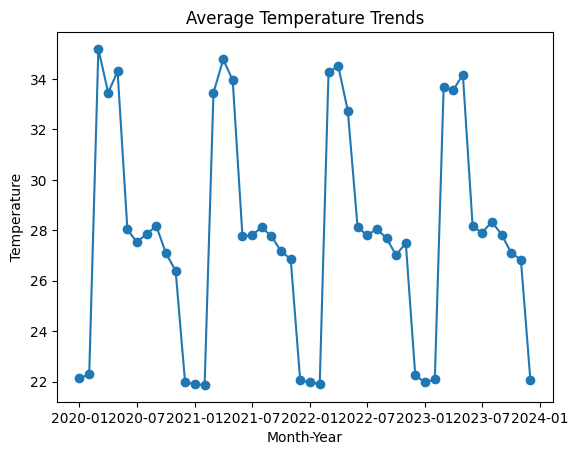

In [ ]:
#Visualizations with Matplotlib

#Line Plot: Show average temperature trends over time (monthly/yearly)

my_temp = df.groupby(['Year','Month'])['Temperature'].mean().reset_index()

#date col

my_temp['Date'] = pd.to_datetime(my_temp[['Year', 'Month']].assign(DAY=1))

#sort by date

my_temp = my_temp.sort_values('Date')

#plot
plt.figure()
plt.plot(my_temp['Date'],my_temp['Temperature'],marker='o')
plt.title('Average Temperature Trends')
plt.xlabel('Month-Year')
plt.ylabel('Temperature')
plt.show()




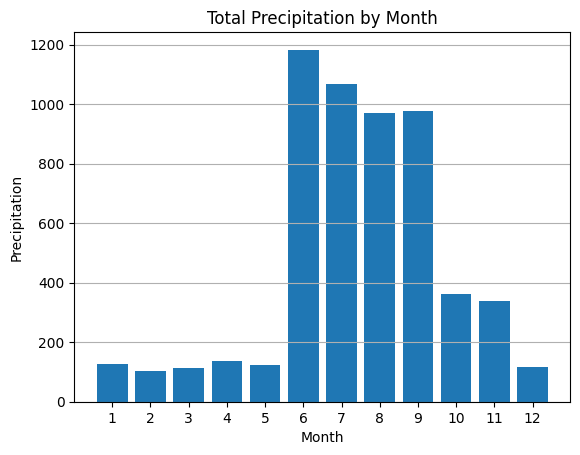

In [ ]:
#Bar Plot: Compare total or average precipitation by month.

#total rainfall in each month

per_month = df.groupby('Month')['Precipitation'].sum().reset_index()

#bar graph

plt.figure()
plt.bar(per_month['Month'],per_month['Precipitation'])
plt.title('Total Precipitation by Month')
plt.xlabel('Month')
plt.ylabel('Precipitation')
plt.xticks(per_month['Month'])

#grid
plt.grid(axis='y')
plt.show()

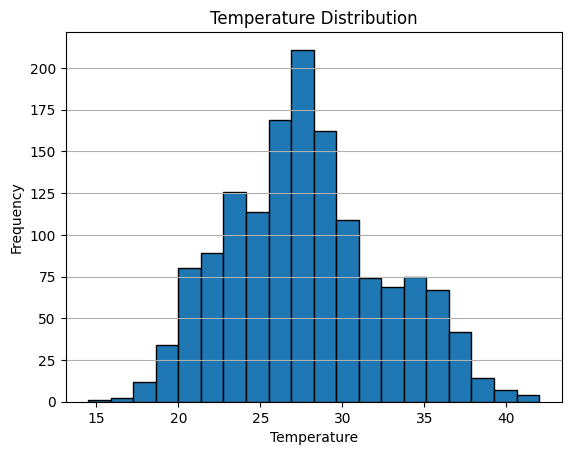

In [ ]:
#Histogram: Show temperature distribution.

plt.figure()
plt.hist(df['Temperature'],bins=20,edgecolor='black')
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')

#gird
plt.grid(axis='y')
plt.show()

In [ ]:
#Identify Extreme Weather
#for extreme temp
# fetch the data from 3rd code sec

high_temp = np.mean(temp_arr) + np.std(temp_arr)

# extreme temp

ext_hot = df[df['Temperature']>high_temp]

print('Extreme Hot Days:')
print(ext_hot)




Extreme Hot Days:
           Date  Temperature  Humidity  Wind_Speed  Precipitation  Month  \
60   2020-03-01         40.5      58.9         4.4            0.3      3   
61   2020-03-02         38.0      33.0        14.0            0.0      3   
62   2020-03-03         37.3      38.5         1.9            0.9      3   
63   2020-03-04         36.0      44.6        13.3            3.8      3   
64   2020-03-05         34.8      37.0        14.2            3.0      3   
...         ...          ...       ...         ...            ...    ...   
1243 2023-05-28         34.8      39.4         3.1            1.0      5   
1245 2023-05-30         37.2      57.0         3.3            0.9      5   
1246 2023-05-31         34.1      37.2        11.1            0.5      5   
1321 2023-08-14         33.9      75.4         1.8            0.8      8   
1365 2023-09-27         33.3      78.8        12.1            0.9      9   

      Year   Season  
60    2020   Summer  
61    2020   Summer  
62 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("/content/realistic_weather_data.csv")

print(df.columns)



Index(['Date', 'Temperature', 'Humidity', 'Wind_Speed', 'Precipitation'], dtype='object')


In [ ]:
temp = np.array(temp_arr)

print(temp)

[25.5 22.8 21.8 ... 24.2 19.2 24.7]


In [ ]:
temp_o = df['Temperature'].values
stdoftemp = np.std(temp_o)
print(stdoftemp)

4.781238466331646


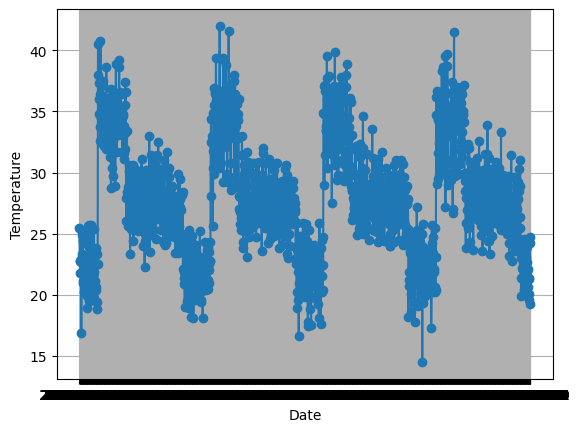

In [ ]:
avgtemp_date = df.groupby('Date')['Temperature'].mean()

plt.figure
plt.plot(avgtemp_date.index,avgtemp_date.values,marker='o')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

This project demonstrates how Python's data analysis libraries can be used to transform raw weather data into meaningful insights. Through statistical analysis, seasonal grouping, visualization, and extreme weather detection, the project successfully identifies important climate patterns and weather trends over a four-year period.

🔍 Key Analysis Performed
Data Cleaning
Converted the Date column to datetime format.
Created additional features:
Month
Year
Season
Verified data types and checked for missing values.
Descriptive Statistics

Calculated:

Mean
Median
Standard Deviation

for:

Temperature
Humidity
Precipitation
Seasonal Analysis

Grouped data by season and calculated average weather metrics.

Key findings:

Summer recorded the highest average temperature (~34°C).
Monsoon had the highest humidity (~82%) and precipitation (~8.6 mm).
Winter showed the lowest average temperature (~22°C).
Monthly Analysis

Compared monthly precipitation and temperature trends to identify seasonal weather variations.

📊 Visualizations
1. Average Temperature Trend

A line plot showing monthly temperature variations across four years.

2. Total Precipitation by Month

A bar chart comparing rainfall across months, highlighting peak monsoon rainfall.

3. Temperature Distribution

A histogram illustrating the frequency distribution of temperature values and identifying common temperature ranges.

🌪️ Extreme Weather Detection

Used NumPy statistical methods to identify:

Extremely hot days
Extremely cold days
Heavy rainfall events

Extreme values were detected using:

Mean ± Standard Deviation for temperature
90th percentile threshold for precipitation
📈 Key Insights
Temperature follows a clear seasonal pattern, peaking during summer and dropping during winter.
Rainfall is concentrated in monsoon months (June–September).
Humidity is highest during monsoon season.
Most temperature values fall between 24°C and 30°C, indicating a relatively stable climate.
Extreme rainfall events occur primarily during the monsoon period.